# 📋 Data Cleaning & EDA Guide (CRISP-DM)

คู่มือสรุปวิธีการทำความสะอาดข้อมูล (Data Cleaning) และการสำรวจข้อมูล (EDA)  
ตามกระบวนการ **CRISP-DM** (Cross-Industry Standard Process for Data Mining)

---
## CRISP-DM 6 ขั้นตอน
1. **Business Understanding** – เข้าใจปัญหาธุรกิจ
2. **Data Understanding** – สำรวจและทำความเข้าใจข้อมูล *(EDA)*
3. **Data Preparation** – เตรียมและทำความสะอาดข้อมูล *(Data Cleaning)*
4. **Modeling** – สร้างโมเดล
5. **Evaluation** – ประเมินผล
6. **Deployment** – นำไปใช้งาน

**Notebook นี้ครอบคลุม ขั้น 2 และ 3**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, Normalizer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.ensemble import IsolationForest

# ใช้ dataset ตัวอย่าง
from sklearn.datasets import load_iris
import warnings
warnings.filterwarnings('ignore')

# สร้าง DataFrame ตัวอย่างที่มีปัญหาต่างๆ เพื่อสาธิต
np.random.seed(42)
df = pd.DataFrame({
    'age':       [25, 30, np.nan, 45, 200, 28, 35, np.nan, 40, 22],
    'salary':    [50000, 60000, 55000, np.nan, 80000, 45000, 70000, 62000, np.nan, 48000],
    'score':     [80, 90, 75, 85, 95, np.nan, 88, 72, 91, 78],
    'gender':    ['M', 'F', 'M', 'F', 'M', 'F', np.nan, 'M', 'F', 'M'],
    'category':  ['A', 'B', 'A', 'C', 'B', 'A', 'C', 'B', 'A', np.nan],
    'purchased': [1, 0, 1, 1, 0, 0, 1, 0, 1, 0]
})
print(df)

     age   salary  score gender category  purchased
0   25.0  50000.0   80.0      M        A          1
1   30.0  60000.0   90.0      F        B          0
2    NaN  55000.0   75.0      M        A          1
3   45.0      NaN   85.0      F        C          1
4  200.0  80000.0   95.0      M        B          0
5   28.0  45000.0    NaN      F        A          0
6   35.0  70000.0   88.0    NaN        C          1
7    NaN  62000.0   72.0      M        B          0
8   40.0      NaN   91.0      F        A          1
9   22.0  48000.0   78.0      M      NaN          0


---
# 1. Data Understanding – สำรวจข้อมูลเบื้องต้น

In [2]:
# ======================================================
# 1.1 ภาพรวมข้อมูล
# ======================================================

print('=== Shape (rows, cols) ===')
print(df.shape)

print('\n=== Data Types ===')
print(df.dtypes)

print('\n=== Head (5 แถวแรก) ===')
print(df.head())

print('\n=== Tail (5 แถวสุดท้าย) ===')
print(df.tail())

print('\n=== Info (ชนิดข้อมูลและ non-null count) ===')
df.info()

# PARAMETERS:
# df.head(n)       → แสดง n แถวแรก (default=5)
# df.tail(n)       → แสดง n แถวสุดท้าย (default=5)
# df.sample(n)     → สุ่มตัวอย่าง n แถว

=== Shape (rows, cols) ===
(10, 6)

=== Data Types ===
age          float64
salary       float64
score        float64
gender        object
category      object
purchased      int64
dtype: object

=== Head (5 แถวแรก) ===
     age   salary  score gender category  purchased
0   25.0  50000.0   80.0      M        A          1
1   30.0  60000.0   90.0      F        B          0
2    NaN  55000.0   75.0      M        A          1
3   45.0      NaN   85.0      F        C          1
4  200.0  80000.0   95.0      M        B          0

=== Tail (5 แถวสุดท้าย) ===
    age   salary  score gender category  purchased
5  28.0  45000.0    NaN      F        A          0
6  35.0  70000.0   88.0    NaN        C          1
7   NaN  62000.0   72.0      M        B          0
8  40.0      NaN   91.0      F        A          1
9  22.0  48000.0   78.0      M      NaN          0

=== Info (ชนิดข้อมูลและ non-null count) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total

In [3]:
# ======================================================
# 1.2 สถิติพรรณนา (Descriptive Statistics)
# ======================================================

print('=== describe() – สถิติ numerical ===')
print(df.describe())
# แสดง: count, mean, std, min, 25%, 50%, 75%, max

print('\n=== describe(include="object") – สถิติ categorical ===')
print(df.describe(include='object'))
# แสดง: count, unique, top (most frequent), freq

print('\n=== describe(include="all") – ทุก column ===' )
# df.describe(include='all')

# PARAMETERS:
# include='number'   → เฉพาะตัวเลข
# include='object'   → เฉพาะ string/categorical
# include='all'      → ทุก column
# percentiles=[.1, .5, .9]  → กำหนด percentile เอง

=== describe() – สถิติ numerical ===
              age      salary      score  purchased
count    8.000000      8.0000   9.000000  10.000000
mean    53.125000  58750.0000  83.777778   0.500000
std     59.838921  11865.3156   7.902180   0.527046
min     22.000000  45000.0000  72.000000   0.000000
25%     27.250000  49500.0000  78.000000   0.000000
50%     32.500000  57500.0000  85.000000   0.500000
75%     41.250000  64000.0000  90.000000   1.000000
max    200.000000  80000.0000  95.000000   1.000000

=== describe(include="object") – สถิติ categorical ===
       gender category
count       9        9
unique      2        3
top         M        A
freq        5        4

=== describe(include="all") – ทุก column ===


In [4]:
# ======================================================
# 1.3 Value Counts – ดูการกระจายค่าใน Categorical
# ======================================================

print('=== value_counts() ===')
print(df['gender'].value_counts())
# นับจำนวนแต่ละค่า เรียงมากไปน้อย

print('\n=== value_counts(normalize=True) – เป็น % ===')
print(df['gender'].value_counts(normalize=True))

print('\n=== value_counts(dropna=False) – รวม NaN ===')
print(df['gender'].value_counts(dropna=False))

# PARAMETERS:
# normalize=True    → แสดงเป็น proportion (0-1)
# ascending=True    → เรียงน้อยไปมาก
# dropna=False      → รวม NaN ในการนับ

=== value_counts() ===
gender
M    5
F    4
Name: count, dtype: int64

=== value_counts(normalize=True) – เป็น % ===
gender
M    0.555556
F    0.444444
Name: proportion, dtype: float64

=== value_counts(dropna=False) – รวม NaN ===
gender
M      5
F      4
NaN    1
Name: count, dtype: int64


---
# 2. Missing Values – ค่าสูญหาย

=== isnull().sum() – นับ NaN แต่ละ column ===
age          2
salary       2
score        1
gender       1
category     1
purchased    0
dtype: int64

=== % ของ missing values ===
age          20.0
salary       20.0
score        10.0
gender       10.0
category     10.0
purchased     0.0
dtype: float64

=== isnull().sum().sum() – NaN ทั้งหมด ===
7


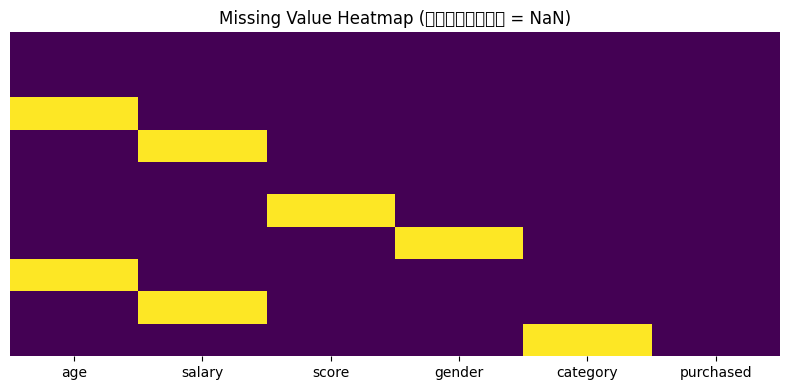

In [5]:
# ======================================================
# 2.1 ตรวจสอบค่าสูญหาย
# ======================================================

print('=== isnull().sum() – นับ NaN แต่ละ column ===')
print(df.isnull().sum())

print('\n=== % ของ missing values ===')
print(df.isnull().sum() / len(df) * 100)

print('\n=== isnull().sum().sum() – NaN ทั้งหมด ===')
print(df.isnull().sum().sum())

# Heatmap แสดง missing values
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Value Heatmap (สีเหลือง = NaN)')
plt.tight_layout()
plt.show()

# PARAMETERS:
# df.isnull()       → True/False matrix
# df.notnull()      → กลับกัน (True = มีค่า)
# df.isna()         → เหมือน isnull()

In [6]:
# ======================================================
# 2.2 การจัดการ Missing Values
# ======================================================

df_clean = df.copy()

# ---- วิธีที่ 1: ลบแถวที่มี NaN ----
df_dropna = df.dropna()
print('dropna() – ลบทุกแถวที่มี NaN:', df_dropna.shape)

df_dropna_thresh = df.dropna(thresh=4)  # เก็บแถวที่มีค่าไม่ใช่ NaN อย่างน้อย 4 ค่า
print('dropna(thresh=4):', df_dropna_thresh.shape)

df_dropna_subset = df.dropna(subset=['age', 'salary'])  # ลบเฉพาะแถวที่ age หรือ salary เป็น NaN
print('dropna(subset=[age,salary]):', df_dropna_subset.shape)

# PARAMETERS dropna:
# axis=0         → ลบ rows (default)
# axis=1         → ลบ columns
# how='any'      → ลบถ้ามี NaN ใดๆ (default)
# how='all'      → ลบถ้า NaN ทั้งแถว/column
# thresh=n       → เก็บแถวที่มีค่า non-NaN อย่างน้อย n ค่า
# subset=[cols]  → ตรวจสอบเฉพาะ columns ที่กำหนด

dropna() – ลบทุกแถวที่มี NaN: (3, 6)
dropna(thresh=4): (10, 6)
dropna(subset=[age,salary]): (6, 6)


In [7]:
# ---- วิธีที่ 2: fillna – เติมค่า ----

# เติมด้วยค่าคงที่
df_fill0 = df.fillna(0)
print('fillna(0):\n', df_fill0[['age','salary','gender']].head())

# เติมด้วย Mean
df_mean = df.copy()
df_mean['age'] = df_mean['age'].fillna(df_mean['age'].mean())
print('\nfillna(mean) – age:', df_mean['age'].values)

# เติมด้วย Median
df_median = df.copy()
df_median['salary'] = df_median['salary'].fillna(df_median['salary'].median())
print('fillna(median) – salary:', df_median['salary'].values)

# เติมด้วย Mode (เหมาะกับ categorical)
df_mode = df.copy()
df_mode['gender'] = df_mode['gender'].fillna(df_mode['gender'].mode()[0])
df_mode['category'] = df_mode['category'].fillna(df_mode['category'].mode()[0])
print('fillna(mode) – gender:', df_mode['gender'].values)

# PARAMETERS fillna:
# value=x         → เติมด้วยค่า x
# method='ffill'  → Forward Fill (ใช้ค่าก่อนหน้า)
# method='bfill'  → Backward Fill (ใช้ค่าถัดไป)
# limit=n         → เติมได้สูงสุด n ค่า
# inplace=True    → เปลี่ยน df เลย (ไม่ return ใหม่)

fillna(0):
      age   salary gender
0   25.0  50000.0      M
1   30.0  60000.0      F
2    0.0  55000.0      M
3   45.0      0.0      F
4  200.0  80000.0      M

fillna(mean) – age: [ 25.     30.     53.125  45.    200.     28.     35.     53.125  40.
  22.   ]
fillna(median) – salary: [50000. 60000. 55000. 57500. 80000. 45000. 70000. 62000. 57500. 48000.]
fillna(mode) – gender: ['M' 'F' 'M' 'F' 'M' 'F' 'M' 'M' 'F' 'M']


In [8]:
# ---- วิธีที่ 3: SimpleImputer (sklearn) ----

from sklearn.impute import SimpleImputer

# Imputer สำหรับ numerical
imp_mean   = SimpleImputer(strategy='mean')      # เติมด้วย mean
imp_median = SimpleImputer(strategy='median')    # เติมด้วย median
imp_most   = SimpleImputer(strategy='most_frequent')  # เติมด้วย mode
imp_const  = SimpleImputer(strategy='constant', fill_value=-1)  # ค่าคงที่

num_cols = ['age', 'salary', 'score']
df_imputed = df.copy()
df_imputed[num_cols] = imp_mean.fit_transform(df[num_cols])
print('SimpleImputer(mean):')
print(df_imputed[num_cols])

# PARAMETERS SimpleImputer:
# strategy='mean'          → ค่าเฉลี่ย (numerical)
# strategy='median'        → มัธยฐาน (numerical, robust to outliers)
# strategy='most_frequent' → ฐานนิยม (categorical หรือ numerical)
# strategy='constant'      → ค่าคงที่ ต้องระบุ fill_value
# fill_value=x             → ค่าที่ใช้เมื่อ strategy='constant'
# missing_values=np.nan    → ระบุว่าค่า missing คืออะไร (default=np.nan)

SimpleImputer(mean):
       age   salary      score
0   25.000  50000.0  80.000000
1   30.000  60000.0  90.000000
2   53.125  55000.0  75.000000
3   45.000  58750.0  85.000000
4  200.000  80000.0  95.000000
5   28.000  45000.0  83.777778
6   35.000  70000.0  88.000000
7   53.125  62000.0  72.000000
8   40.000  58750.0  91.000000
9   22.000  48000.0  78.000000


In [9]:
# ---- วิธีที่ 4: KNNImputer – เติมด้วย K เพื่อนบ้านใกล้สุด ----

from sklearn.impute import KNNImputer

knn_imp = KNNImputer(n_neighbors=3, weights='uniform')
df_knn = df.copy()
df_knn[num_cols] = knn_imp.fit_transform(df[num_cols])
print('KNNImputer(n_neighbors=3):')
print(df_knn[num_cols])

# PARAMETERS KNNImputer:
# n_neighbors=5      → จำนวนเพื่อนบ้าน (default=5)
# weights='uniform'  → น้ำหนักเท่ากัน (default)
# weights='distance' → น้ำหนักตามระยะห่าง (ใกล้ = สำคัญกว่า)
# metric='nan_euclidean' → วิธีวัดระยะห่าง
# เหมาะเมื่อ: ข้อมูลมี pattern ที่ค่าใกล้เคียงกันน่าจะสัมพันธ์กัน

KNNImputer(n_neighbors=3):
          age        salary      score
0   25.000000  50000.000000  80.000000
1   30.000000  60000.000000  90.000000
2   36.666667  55000.000000  75.000000
3   45.000000  61666.666667  85.000000
4  200.000000  80000.000000  95.000000
5   28.000000  45000.000000  84.666667
6   35.000000  70000.000000  88.000000
7   38.333333  62000.000000  72.000000
8   40.000000  58333.333333  91.000000
9   22.000000  48000.000000  78.000000


---
# 3. Outlier Detection – ตรวจสอบค่าผิดปกติ

Age bounds: lower=6.2, upper=62.2
Outliers: [200.]


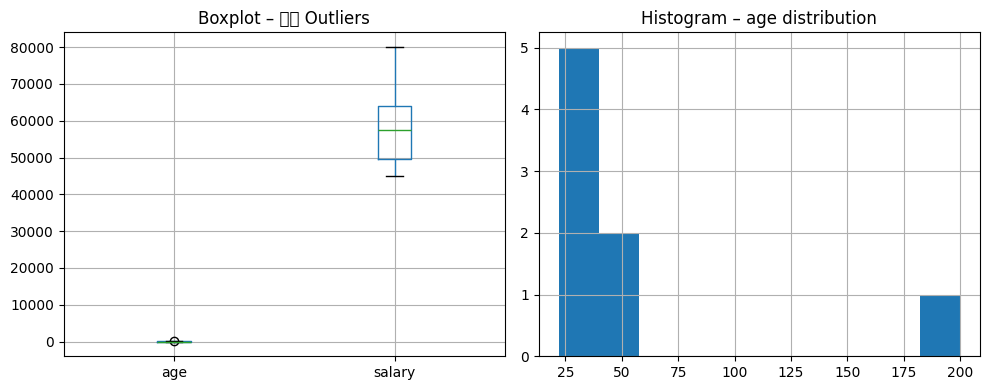

In [10]:
# ======================================================
# 3.1 IQR Method (Interquartile Range)
# ======================================================

def detect_outliers_iqr(series, factor=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    return series[(series < lower) | (series > upper)], lower, upper

outliers, low, high = detect_outliers_iqr(df['age'].dropna())
print(f'Age bounds: lower={low:.1f}, upper={high:.1f}')
print(f'Outliers: {outliers.values}')

# วิธีใช้ IQR:
# factor=1.5   → standard (mild outliers)
# factor=3.0   → extreme outliers เท่านั้น

# Boxplot ดู outlier
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df[['age', 'salary']].boxplot(ax=axes[0])
axes[0].set_title('Boxplot – ดู Outliers')
df['age'].hist(bins=10, ax=axes[1])
axes[1].set_title('Histogram – age distribution')
plt.tight_layout()
plt.show()

In [11]:
# ======================================================
# 3.2 Z-Score Method
# ======================================================

from scipy import stats

df_num = df[['age', 'salary']].dropna()
z_scores = np.abs(stats.zscore(df_num))
outlier_mask = (z_scores > 3).any(axis=1)
print('Z-Score Outliers (z > 3):')
print(df_num[outlier_mask])

# วิธีใช้ Z-Score:
# threshold=3  → ปกติใช้ 2 หรือ 3
# z > 3        → ห่างจาก mean มากกว่า 3 std deviations
# เหมาะเมื่อ: ข้อมูลกระจายแบบ normal distribution

Z-Score Outliers (z > 3):
Empty DataFrame
Columns: [age, salary]
Index: []


In [12]:
# ======================================================
# 3.3 Isolation Forest
# ======================================================

from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.1, random_state=42)
df_num2 = df[num_cols].fillna(df[num_cols].mean())
labels = iso.fit_predict(df_num2)
# +1 = inlier (ปกติ), -1 = outlier

print('Isolation Forest labels:', labels)
print('Outlier rows:')
print(df[labels == -1])

# PARAMETERS IsolationForest:
# n_estimators=100     → จำนวนต้นไม้ (default=100)
# contamination=0.1    → สัดส่วน outlier ที่คาดว่ามี (0-0.5)
# max_samples='auto'   → จำนวน samples ต่อต้น
# random_state=42      → เพื่อ reproducibility
# เหมาะเมื่อ: ข้อมูลหลาย dimension, ไม่รู้ distribution

Isolation Forest labels: [ 1  1  1  1 -1  1  1  1  1  1]
Outlier rows:
     age   salary  score gender category  purchased
4  200.0  80000.0   95.0      M        B          0


In [13]:
# ======================================================
# 3.4 จัดการ Outliers
# ======================================================

df_out = df.copy()
df_out['age'] = df_out['age'].fillna(df_out['age'].median())

# วิธีที่ 1: ลบแถว outlier
Q1, Q3 = df_out['age'].quantile([0.25, 0.75])
IQR = Q3 - Q1
df_no_outlier = df_out[(df_out['age'] >= Q1 - 1.5*IQR) & 
                        (df_out['age'] <= Q3 + 1.5*IQR)]
print('หลังลบ outlier:', df_no_outlier['age'].values)

# วิธีที่ 2: Capping/Clipping – จำกัดค่าสูงสุด/ต่ำสุด
df_clip = df_out.copy()
lower_cap = df_clip['age'].quantile(0.05)
upper_cap = df_clip['age'].quantile(0.95)
df_clip['age'] = df_clip['age'].clip(lower_cap, upper_cap)
print('หลัง clipping:', df_clip['age'].values)

# PARAMETERS clip:
# lower=x    → ค่าต่ำสุดที่อนุญาต
# upper=x    → ค่าสูงสุดที่อนุญาต

# วิธีที่ 3: แทนด้วย median
df_replace = df_out.copy()
median_age = df_replace['age'].median()
df_replace.loc[df_replace['age'] > 100, 'age'] = median_age
print('หลังแทน outlier ด้วย median:', df_replace['age'].values)

หลังลบ outlier: [25.  30.  32.5 45.  28.  35.  32.5 40.  22. ]
หลัง clipping: [ 25.    30.    32.5   45.   130.25  28.    35.    32.5   40.    23.35]
หลังแทน outlier ด้วย median: [25.  30.  32.5 45.  32.5 28.  35.  32.5 40.  22. ]


---
# 4. Feature Scaling – การปรับขนาดค่า

| วิธี | สูตร | เมื่อไหร่ใช้ |
|------|------|-------------|
| StandardScaler | (x - mean) / std → mean=0, std=1 | ทั่วไป, Linear models, SVM, PCA |
| MinMaxScaler | (x - min) / (max - min) → [0,1] | Neural Networks, KNN, เมื่อรู้ขอบเขต |
| RobustScaler | (x - median) / IQR → robust ต่อ outlier | มี outlier เยอะ |
| Normalizer | ปรับแต่ละ row ให้ norm=1 | Text, cosine similarity |

In [14]:
# ======================================================
# 4.1 StandardScaler (Z-score Normalization)
# ======================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = df_imputed.copy()
df_scaled[num_cols] = scaler.fit_transform(df_imputed[num_cols])

print('StandardScaler:')
print(df_scaled[num_cols].describe().round(2))
# mean ≈ 0, std ≈ 1

# กลับค่าเดิม
df_original_back = scaler.inverse_transform(df_scaled[num_cols])

# PARAMETERS StandardScaler:
# with_mean=True    → ลบด้วย mean (default=True)
# with_std=True     → หารด้วย std (default=True)
# copy=True         → copy data ก่อน (default=True)

# METHODS:
# .fit(X)              → เรียนรู้ mean/std จาก training data
# .transform(X)        → ปรับ scale ตาม mean/std ที่เรียนรู้มา
# .fit_transform(X)    → fit + transform พร้อมกัน
# .inverse_transform(X) → กลับค่าเดิม

StandardScaler:
         age  salary  score
count  10.00   10.00  10.00
mean    0.00    0.00  -0.00
std     1.05    1.05   1.05
min    -0.62   -1.39  -1.67
25%    -0.49   -0.76  -0.75
50%    -0.31    0.00   0.09
75%    -0.04    0.28   0.81
max     2.93    2.14   1.59


In [15]:
# ======================================================
# 4.2 MinMaxScaler
# ======================================================

from sklearn.preprocessing import MinMaxScaler

mm_scaler = MinMaxScaler(feature_range=(0, 1))
df_minmax = df_imputed.copy()
df_minmax[num_cols] = mm_scaler.fit_transform(df_imputed[num_cols])

print('MinMaxScaler (0 to 1):')
print(df_minmax[num_cols].describe().round(3))
# min=0, max=1

# PARAMETERS MinMaxScaler:
# feature_range=(0, 1)   → ช่วงที่ต้องการ (default=(0,1))
# feature_range=(-1, 1)  → ช่วง -1 ถึง 1 สำหรับ neural networks
# copy=True              → copy data

MinMaxScaler (0 to 1):
          age  salary   score
count  10.000  10.000  10.000
mean    0.175   0.393   0.512
std     0.296   0.299   0.324
min     0.000   0.000   0.000
25%     0.037   0.179   0.283
50%     0.087   0.393   0.539
75%     0.163   0.471   0.761
max     1.000   1.000   1.000


In [16]:
# ======================================================
# 4.3 RobustScaler
# ======================================================

from sklearn.preprocessing import RobustScaler

rob_scaler = RobustScaler(quantile_range=(25, 75))
df_robust = df_imputed.copy()
df_robust[num_cols] = rob_scaler.fit_transform(df_imputed[num_cols])

print('RobustScaler (ต้านทาน outlier):')
print(df_robust[num_cols].describe().round(2))

# PARAMETERS RobustScaler:
# with_centering=True    → ลบด้วย median (default=True)
# with_scaling=True      → หารด้วย IQR (default=True)
# quantile_range=(25,75) → ช่วง IQR (default=(25,75))

RobustScaler (ต้านทาน outlier):
         age  salary  score
count  10.00   10.00  10.00
mean    0.69    0.00  -0.06
std     2.34    1.02   0.68
min    -0.69   -1.34  -1.13
25%    -0.40   -0.73  -0.54
50%     0.00    0.00   0.00
75%     0.60    0.27   0.46
max     7.19    2.07   0.96


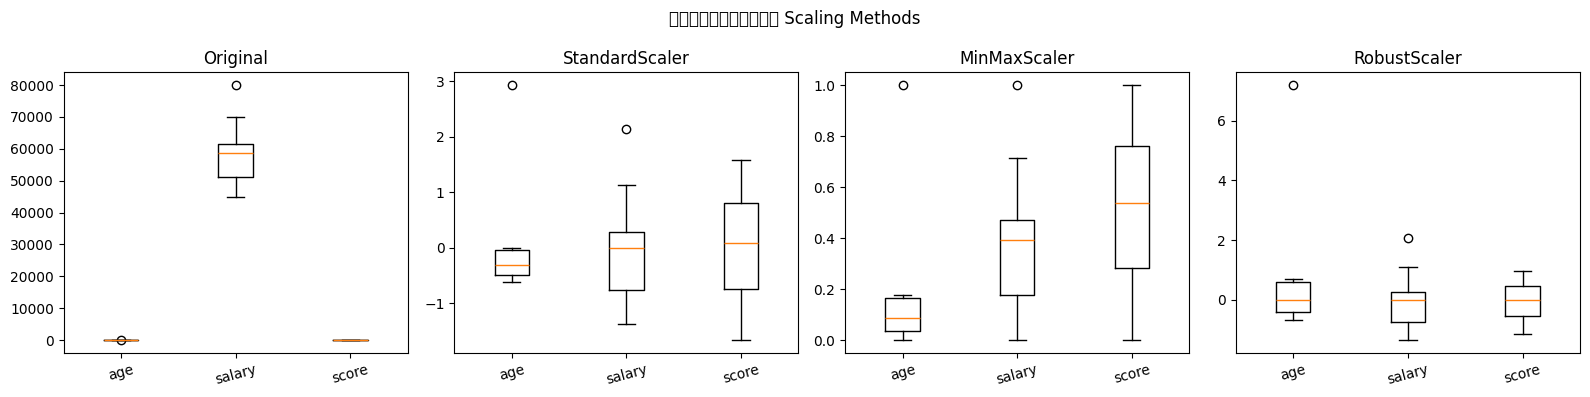

In [17]:
# ======================================================
# 4.4 เปรียบเทียบ Scalers
# ======================================================

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

titles = ['Original', 'StandardScaler', 'MinMaxScaler', 'RobustScaler']
datas = [df_imputed[num_cols], df_scaled[num_cols], 
         df_minmax[num_cols], df_robust[num_cols]]

for ax, title, data in zip(axes, titles, datas):
    ax.boxplot(data.values)
    ax.set_xticklabels(num_cols, rotation=15)
    ax.set_title(title)

plt.suptitle('เปรียบเทียบ Scaling Methods')
plt.tight_layout()
plt.show()

---
# 5. Normalization – การทำ Normalize

> **ต่างจาก Scaling:** Normalization ปรับแต่ละ **row (sample)** ให้มี norm = 1  
> Scaling ปรับแต่ละ **column (feature)** ให้อยู่ในช่วงที่ต้องการ

In [18]:
# ======================================================
# 5.1 Normalizer (sklearn)
# ======================================================

from sklearn.preprocessing import Normalizer

# L2 Norm: sqrt(x1²+x2²+...) = 1
norm_l2 = Normalizer(norm='l2')
df_norm_l2 = norm_l2.fit_transform(df_imputed[num_cols])
print('Normalizer (L2) – norm ของแต่ละแถว:')
print(np.linalg.norm(df_norm_l2, axis=1).round(4))
# ทุกแถวจะ = 1.0

# L1 Norm: |x1|+|x2|+... = 1
norm_l1 = Normalizer(norm='l1')
df_norm_l1 = norm_l1.fit_transform(df_imputed[num_cols])
print('\nNormalizer (L1):')
print(np.abs(df_norm_l1).sum(axis=1).round(4))

# PARAMETERS Normalizer:
# norm='l2'    → Euclidean norm (default) – ใช้กับ cosine similarity
# norm='l1'    → Manhattan norm – ใช้กับ sparse data, text
# norm='max'   → หารด้วยค่าสูงสุดใน row
# copy=True    → copy data

Normalizer (L2) – norm ของแต่ละแถว:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Normalizer (L1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


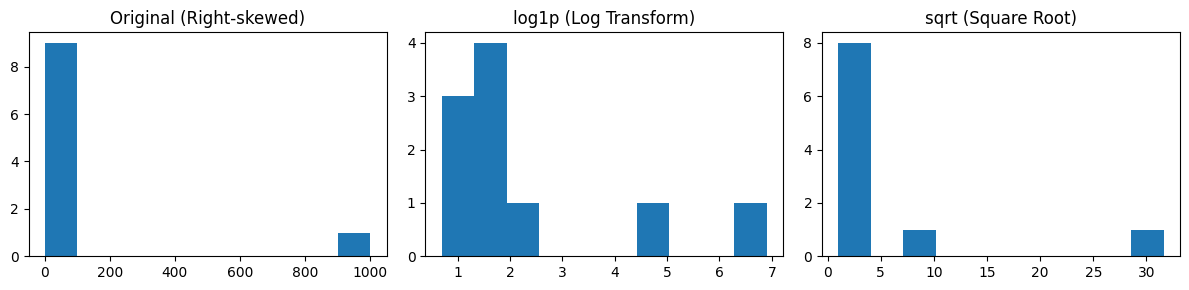

In [19]:
# ======================================================
# 5.2 Log Transformation – สำหรับ skewed data
# ======================================================

# สร้างข้อมูล skewed
skewed_data = np.array([1, 2, 2, 3, 3, 3, 5, 10, 100, 1000])

fig, axes = plt.subplots(1, 3, figsize=(12, 3))

axes[0].hist(skewed_data, bins=10)
axes[0].set_title('Original (Right-skewed)')

axes[1].hist(np.log1p(skewed_data), bins=10)
axes[1].set_title('log1p (Log Transform)')

axes[2].hist(np.sqrt(skewed_data), bins=10)
axes[2].set_title('sqrt (Square Root)')

plt.tight_layout()
plt.show()

# np.log1p(x)  = log(x+1)  → ใช้เมื่อมีค่า 0
# np.log(x)    = ln(x)     → ใช้เมื่อทุกค่า > 0
# np.sqrt(x)   = sqrt(x)   → mild skew
# x**(1/3)     = cube root → สำหรับค่าลบได้ด้วย

# PowerTransformer: Box-Cox, Yeo-Johnson (auto-detect best transform)
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson')  # yeo-johnson รับค่าลบได้
# pt = PowerTransformer(method='box-cox')   # box-cox ต้องการค่า > 0

---
# 6. Encoding – แปลง Categorical เป็นตัวเลข

In [20]:
# ======================================================
# 6.1 Label Encoding – แปลง label เป็นเลข 0,1,2...
# ======================================================

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_enc = df_mode.copy()  # df ที่เติม NaN ด้วย mode แล้ว
df_enc['gender_enc'] = le.fit_transform(df_enc['gender'])
print('LabelEncoder – gender:')
print(df_enc[['gender','gender_enc']])
print('Classes:', le.classes_)

# METHODS:
# .fit(y)               → เรียนรู้ labels
# .transform(y)         → แปลงเป็นตัวเลข
# .inverse_transform(y) → กลับเป็น labels เดิม
# .classes_             → ดู labels ที่รู้จัก

# ⚠️ ระวัง: LabelEncoder บอกให้ model คิดว่า 0 < 1 < 2 (มี order)
# ใช้เฉพาะ ordinal data หรือ target variable

LabelEncoder – gender:
  gender  gender_enc
0      M           1
1      F           0
2      M           1
3      F           0
4      M           1
5      F           0
6      M           1
7      M           1
8      F           0
9      M           1
Classes: ['F' 'M']


In [21]:
# ======================================================
# 6.2 One-Hot Encoding – แปลงเป็น binary columns
# ======================================================

# วิธีที่ 1: pandas get_dummies
df_ohe = pd.get_dummies(df_mode, columns=['gender', 'category'], drop_first=False)
print('get_dummies:')
print(df_ohe.head())

# PARAMETERS get_dummies:
# columns=[...]     → columns ที่ต้องการ encode
# drop_first=True   → ลบ column แรกออก (ป้องกัน dummy variable trap)
# prefix='cat'      → prefix ของชื่อ column ใหม่
# dtype=int         → ชนิดข้อมูลของ output (default=bool)

# วิธีที่ 2: sklearn OneHotEncoder
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')

# PARAMETERS OneHotEncoder:
# sparse_output=False  → return dense array (default=True/sparse)
# drop='first'         → ลบ column แรก
# drop='if_binary'     → ลบเฉพาะ binary features
# handle_unknown='ignore'  → ค่าใหม่ที่ไม่รู้จัก → all zeros
# handle_unknown='error'   → raise error (default)

get_dummies:
     age   salary  score  purchased  gender_F  gender_M  category_A  \
0   25.0  50000.0   80.0          1     False      True        True   
1   30.0  60000.0   90.0          0      True     False       False   
2    NaN  55000.0   75.0          1     False      True        True   
3   45.0      NaN   85.0          1      True     False       False   
4  200.0  80000.0   95.0          0     False      True       False   

   category_B  category_C  
0       False       False  
1        True       False  
2       False       False  
3       False        True  
4        True       False  


In [22]:
# ======================================================
# 6.3 Ordinal Encoding – สำหรับข้อมูลที่มี order
# ======================================================

from sklearn.preprocessing import OrdinalEncoder

# ตัวอย่าง: ระดับการศึกษา มี order จริง
edu_data = pd.DataFrame({'education': ['High School', 'Bachelor', 'Master', 'PhD', 'Bachelor']})
oe = OrdinalEncoder(categories=[['High School', 'Bachelor', 'Master', 'PhD']])
edu_data['edu_encoded'] = oe.fit_transform(edu_data[['education']])
print('OrdinalEncoder:')
print(edu_data)

# PARAMETERS OrdinalEncoder:
# categories='auto'         → เรียง alphabetically
# categories=[[...]]        → กำหนด order เอง (แนะนำ)
# handle_unknown='error'    → ค่าใหม่ทำให้ error
# handle_unknown='use_encoded_value', unknown_value=-1

OrdinalEncoder:
     education  edu_encoded
0  High School          0.0
1     Bachelor          1.0
2       Master          2.0
3          PhD          3.0
4     Bachelor          1.0


---
# 7. EDA – Exploratory Data Analysis

การสำรวจข้อมูลด้วยวิธีต่างๆ

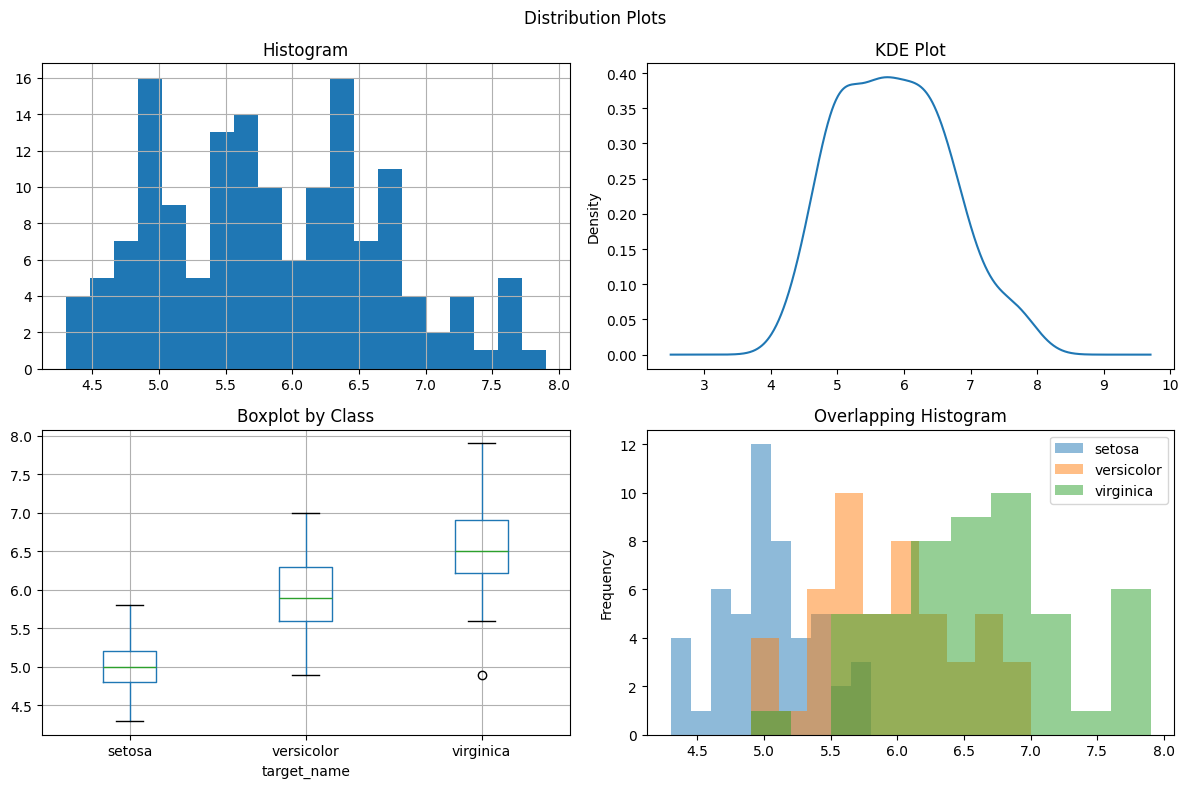

In [23]:
# ======================================================
# 7.1 Distribution – การกระจายตัวของข้อมูล
# ======================================================

from sklearn.datasets import load_iris
iris = load_iris(as_frame=True)
df_iris = iris.frame
df_iris['target_name'] = df_iris['target'].map({0:'setosa', 1:'versicolor', 2:'virginica'})

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Histogram
df_iris['sepal length (cm)'].hist(bins=20, ax=axes[0,0])
axes[0,0].set_title('Histogram')

# KDE (Kernel Density Estimate)
df_iris['sepal length (cm)'].plot.kde(ax=axes[0,1])
axes[0,1].set_title('KDE Plot')

# Boxplot
df_iris.boxplot(column='sepal length (cm)', by='target_name', ax=axes[1,0])
axes[1,0].set_title('Boxplot by Class')

# Violin plot
df_iris.groupby('target_name')['sepal length (cm)'].plot.hist(ax=axes[1,1], alpha=0.5)
axes[1,1].set_title('Overlapping Histogram')
axes[1,1].legend()

plt.suptitle('Distribution Plots')
plt.tight_layout()
plt.show()

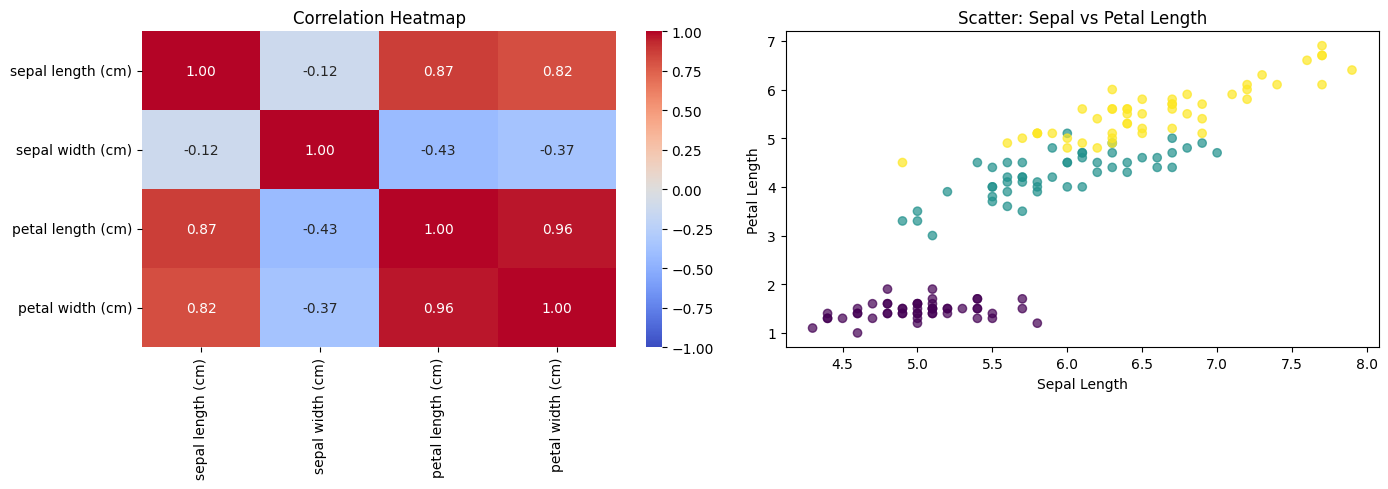

Correlation values:
                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   

                   petal width (cm)  
sepal length (cm)          0.817941  
sepal width (cm)          -0.366126  
petal length (cm)          0.962865  
petal width (cm)           1.000000  


In [24]:
# ======================================================
# 7.2 Correlation – ความสัมพันธ์ระหว่าง Features
# ======================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation Matrix
corr = df_iris.drop(columns=['target','target_name']).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Correlation Heatmap')

# Scatter plot + regression line
axes[1].scatter(df_iris['sepal length (cm)'], df_iris['petal length (cm)'], 
                c=df_iris['target'], cmap='viridis', alpha=0.7)
axes[1].set_xlabel('Sepal Length')
axes[1].set_ylabel('Petal Length')
axes[1].set_title('Scatter: Sepal vs Petal Length')

plt.tight_layout()
plt.show()

print('Correlation values:')
print(corr)

# corr() PARAMETERS:
# method='pearson'   → linear correlation (default)
# method='spearman'  → rank correlation (non-linear)
# method='kendall'   → rank correlation (robust)

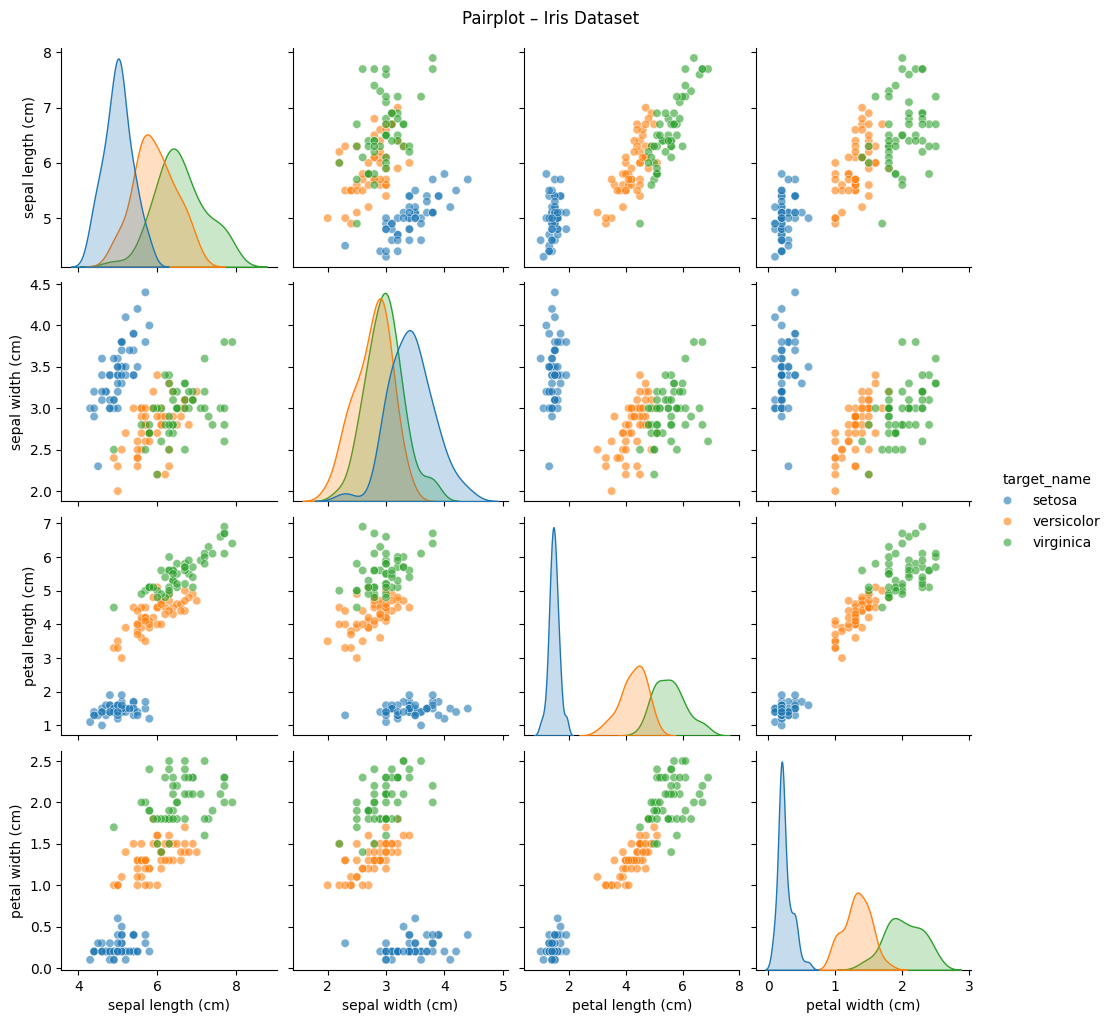

In [25]:
# ======================================================
# 7.3 Pairplot – ดู relationship ทุก pairs พร้อมกัน
# ======================================================

g = sns.pairplot(
    df_iris.drop(columns='target'), 
    hue='target_name',      # สีตาม class
    diag_kind='kde',        # diagonal: kde หรือ hist
    plot_kws={'alpha': 0.6}
)
g.fig.suptitle('Pairplot – Iris Dataset', y=1.02)
plt.show()

# PARAMETERS pairplot:
# hue=col_name     → สีตาม categorical column
# diag_kind='kde'  → diagonal: 'kde' หรือ 'hist'
# kind='scatter'   → off-diagonal: 'scatter', 'reg', 'kde'
# corner=True      → แสดงครึ่งเดียว
# vars=[...]       → เลือก columns ที่จะแสดง

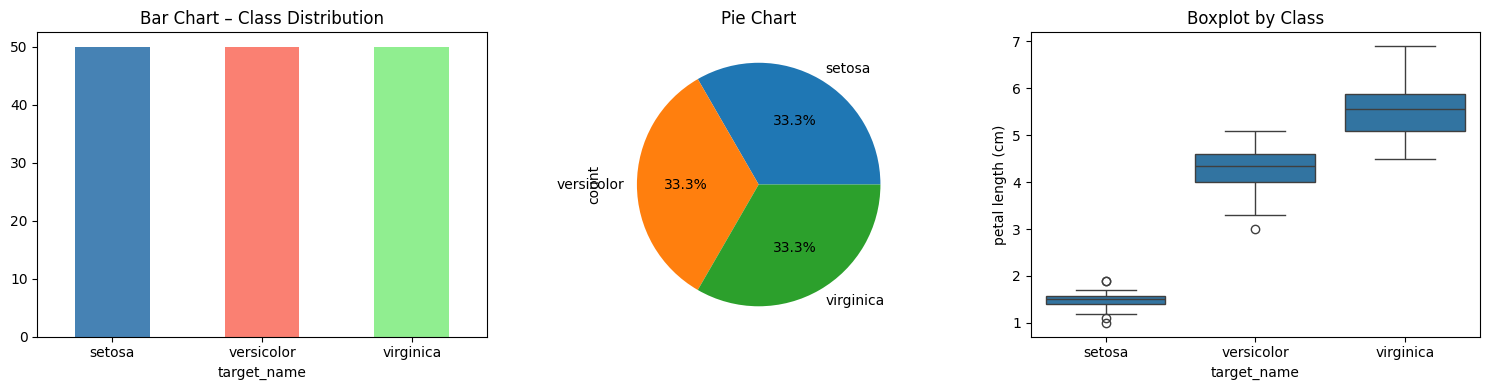

In [26]:
# ======================================================
# 7.4 Categorical EDA
# ======================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Bar chart
df_iris['target_name'].value_counts().plot.bar(ax=axes[0], color=['steelblue','salmon','lightgreen'])
axes[0].set_title('Bar Chart – Class Distribution')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
df_iris['target_name'].value_counts().plot.pie(ax=axes[1], autopct='%1.1f%%')
axes[1].set_title('Pie Chart')

# Grouped boxplot (seaborn)
sns.boxplot(data=df_iris, x='target_name', y='petal length (cm)', ax=axes[2])
axes[2].set_title('Boxplot by Class')

plt.tight_layout()
plt.show()

In [27]:
# ======================================================
# 7.5 Skewness & Kurtosis
# ======================================================

print('=== Skewness (ความเบ้) ===')
print(df_iris.drop(columns=['target','target_name']).skew())
print('\n> 0  = เบ้ขวา (right-skewed, long tail ขวา)')
print('< 0  = เบ้ซ้าย (left-skewed)')
print('≈ 0  = สมมาตร')

print('\n=== Kurtosis (ความแหลม) ===')
print(df_iris.drop(columns=['target','target_name']).kurt())
print('\n> 0  = หางหนัก (มี outlier มาก)')
print('< 0  = หางเบา')
print('≈ 0  = ใกล้ normal distribution')

# Skew > 1 หรือ < -1 → ควรทำ transformation

=== Skewness (ความเบ้) ===
sepal length (cm)    0.314911
sepal width (cm)     0.318966
petal length (cm)   -0.274884
petal width (cm)    -0.102967
dtype: float64

> 0  = เบ้ขวา (right-skewed, long tail ขวา)
< 0  = เบ้ซ้าย (left-skewed)
≈ 0  = สมมาตร

=== Kurtosis (ความแหลม) ===
sepal length (cm)   -0.552064
sepal width (cm)     0.228249
petal length (cm)   -1.402103
petal width (cm)    -1.340604
dtype: float64

> 0  = หางหนัก (มี outlier มาก)
< 0  = หางเบา
≈ 0  = ใกล้ normal distribution


In [28]:
# ======================================================
# 7.6 Profiling แบบรวดเร็ว
# ======================================================

def quick_profile(df):
    """สรุปข้อมูลสำหรับ EDA เบื้องต้น"""
    print(f'Shape: {df.shape}')
    print(f'Duplicates: {df.duplicated().sum()}')
    print()
    
    profile = pd.DataFrame({
        'dtype': df.dtypes,
        'null_count': df.isnull().sum(),
        'null_%': (df.isnull().sum() / len(df) * 100).round(1),
        'nunique': df.nunique(),
        'min': df.min(numeric_only=True),
        'max': df.max(numeric_only=True),
        'mean': df.mean(numeric_only=True).round(2),
        'std': df.std(numeric_only=True).round(2),
        'skew': df.skew(numeric_only=True).round(2),
    })
    return profile

print(quick_profile(df_iris))

Shape: (150, 6)
Duplicates: 1

                     dtype  null_count  null_%  nunique  min  max  mean   std  \
petal length (cm)  float64           0     0.0       43  1.0  6.9  3.76  1.77   
petal width (cm)   float64           0     0.0       22  0.1  2.5  1.20  0.76   
sepal length (cm)  float64           0     0.0       35  4.3  7.9  5.84  0.83   
sepal width (cm)   float64           0     0.0       23  2.0  4.4  3.06  0.44   
target               int64           0     0.0        3  0.0  2.0  1.00  0.82   
target_name         object           0     0.0        3  NaN  NaN   NaN   NaN   

                   skew  
petal length (cm) -0.27  
petal width (cm)  -0.10  
sepal length (cm)  0.31  
sepal width (cm)   0.32  
target             0.00  
target_name         NaN  


---
# 8. Duplicate Detection – ค่าซ้ำ

In [29]:
# ======================================================
# 8.1 ตรวจสอบและลบ Duplicates
# ======================================================

df_dup = pd.concat([df.head(3), df.head(3), df.tail(2)]).reset_index(drop=True)

print('จำนวน duplicate rows:', df_dup.duplicated().sum())
print('\nแถวที่ซ้ำ:')
print(df_dup[df_dup.duplicated()])

# ลบ duplicates
df_dedup = df_dup.drop_duplicates()
print('\nหลังลบ duplicates:', df_dedup.shape)

# ลบ duplicates บาง column
df_dedup2 = df_dup.drop_duplicates(subset=['age', 'salary'])

# PARAMETERS drop_duplicates:
# subset=[cols]    → ตรวจเฉพาะ columns เหล่านี้
# keep='first'     → เก็บอันแรก (default)
# keep='last'      → เก็บอันสุดท้าย
# keep=False       → ลบทุกแถวที่ซ้ำกัน
# inplace=True     → แก้ไข df เลย

จำนวน duplicate rows: 3

แถวที่ซ้ำ:
    age   salary  score gender category  purchased
3  25.0  50000.0   80.0      M        A          1
4  30.0  60000.0   90.0      F        B          0
5   NaN  55000.0   75.0      M        A          1

หลังลบ duplicates: (5, 6)


---
# 9. Data Type Cleaning
# 10. Pipelines – รวมทุกขั้นตอน

In [30]:
# ======================================================
# 9. แก้ไข Data Types
# ======================================================

df_types = pd.DataFrame({
    'age':    ['25', '30', '35'],
    'salary': ['50000.5', '60000.0', '55000'],
    'date':   ['2024-01-15', '2024-03-20', '2024-06-10'],
    'flag':   ['true', 'false', 'true']
})

print('Before:', df_types.dtypes)

df_types['age']    = df_types['age'].astype(int)
df_types['salary'] = df_types['salary'].astype(float)
df_types['date']   = pd.to_datetime(df_types['date'])
df_types['flag']   = df_types['flag'].map({'true': True, 'false': False})

print('After:', df_types.dtypes)

# pd.to_numeric(s, errors='coerce') → แปลงตัวเลข, ค่าแปลกเป็น NaN
# pd.to_datetime(s, format='%Y-%m-%d') → แปลงวันที่
# astype({'col': dtype}) → แปลงหลาย columns พร้อมกัน

Before: age       object
salary    object
date      object
flag      object
dtype: object
After: age                int64
salary           float64
date      datetime64[ns]
flag                bool
dtype: object


In [31]:
# ======================================================
# 10. sklearn Pipeline – รวมทุกขั้นตอนเป็น pipeline
# ======================================================

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# กำหนด columns
num_features = ['age', 'salary', 'score']
cat_features = ['gender', 'category']

# Pipeline สำหรับ numerical
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # เติม missing
    ('scaler', StandardScaler()),                   # scale
])

# Pipeline สำหรับ categorical
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  # เติม missing
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore')),  # encode
])

# รวม pipelines
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features),
])

# Full pipeline รวมโมเดล
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=200)),
])

# ใช้งาน
X = df[num_features + cat_features]
y = df['purchased']
full_pipeline.fit(X, y)
predictions = full_pipeline.predict(X)
print('Predictions:', predictions)
print('Pipeline steps:', [step[0] for step in full_pipeline.steps])

Predictions: [1 0 1 1 0 0 1 0 1 1]
Pipeline steps: ['preprocessor', 'classifier']


---
# สรุปตารางวิธีจัดการข้อมูล

## Missing Values
| วิธี | เหมาะกับ | ข้อควรระวัง |
|------|----------|-------------|
| `dropna()` | missing น้อย (<5%) | สูญเสียข้อมูล |
| `fillna(mean)` | numerical, symmetric | ไวต่อ outlier |
| `fillna(median)` | numerical, skewed/outlier | ค่ากลางที่ robust |
| `fillna(mode)` | categorical | อาจ bias ต่อค่าที่พบบ่อย |
| `KNNImputer` | มี pattern ใน data | ช้ากับ large data |
| `fillna(method='ffill')` | time series | ใช้ค่าก่อนหน้า |

## Outliers
| วิธี | เหมาะกับ | threshold |
|------|----------|----------|
| IQR | skewed data | factor=1.5 |
| Z-Score | normal distribution | z > 3 |
| Isolation Forest | multivariate, unknown dist | contamination |
| Clipping | ทั่วไป | percentile 1%/99% |

## Scaling
| วิธี | ผล | ใช้เมื่อ |
|------|-----|----------|
| StandardScaler | mean=0, std=1 | Linear, SVM, PCA, default |
| MinMaxScaler | [0,1] | Neural Net, KNN, กำหนดขอบเขต |
| RobustScaler | median=0 | มี outlier เยอะ |
| Normalizer(L2) | norm=1 ต่อ row | Text, cosine sim |
| Log/Sqrt | ลด skew | right-skewed data |

## Encoding
| วิธี | ใช้เมื่อ |
|------|---------|
| LabelEncoder | Target variable, binary |
| OneHotEncoder / get_dummies | Nominal (ไม่มี order) |
| OrdinalEncoder | Ordinal (มี order) |

---
> **เคล็ดลับ:** ใช้ `Pipeline` เสมอเพื่อป้องกัน **data leakage** – fit บน train set, transform บน test set